# Mean-centred time-frequency analysis



In [1]:
import numpy as np
import mne
from mne.datasets import sample
from mne.stats import permutation_cluster_test

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_filt-0-40_raw.fif"

raw = mne.io.read_raw_fif(raw_fname)
events = mne.find_events(raw, stim_channel="STI 014")

raw.info["bads"] += ["EEG 053"] 

picks = mne.pick_types(
    raw.info,
    meg=False,
    eeg=True,
    eog=True,
    stim=False,
    exclude="bads",
)

# Extract epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id={
        "Auditory/left": 1,
        "Auditory/right": 2,
        "visual/left": 3,
        "visual/right": 4
    },
    tmin=-0.5, tmax=1,
    picks=picks,
    baseline=(None, 0),
    reject=dict(eog=150e-6),
    preload=True,
    verbose=False
)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


## Perform time-frequency decomposition

In [2]:
tfr_kwargs = dict(
    method="morlet",
    freqs=np.exp(np.linspace(np.log(7), np.log(30), 10)), # log space freqs
    n_cycles=1.5,
    decim=5,
    return_itc=False,
    average=False,
)
tfr = epochs.compute_tfr(**tfr_kwargs)
tfr.data = 10*np.log10(tfr.data)
tfr = tfr.apply_baseline(mode="mean", baseline=(None, 0))
tfr = tfr.crop(tmin=-0.2, tmax=0.5)

Applying baseline correction (mode: mean)


## Fit mean-centred model

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: ylabel='Brain score'>,
        <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>], dtype=object))

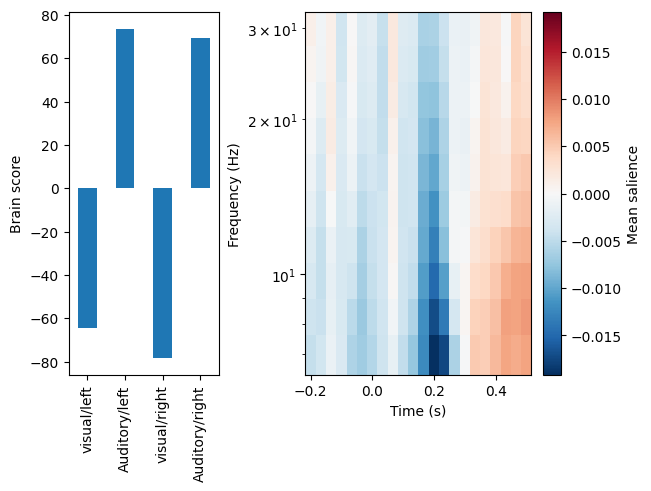

In [3]:
import mne_plsc

labels = mne_plsc.utils.get_epoch_labels(tfr)
res = mne_plsc.fit_mc(tfr, between=labels, random_state=123)
res.plot_lv(0)

In [4]:
res.permute(100)
print(res.summary())

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 47.74it/s]

   LV index  singular value  variance explained   p value
0         0      143.502374            0.531556  0.009901
1         1      101.366003            0.265226  0.019802
2         2       88.729053            0.203218  0.118812
3         3        0.000000            0.000000       NaN


In [5]:
res.bootstrap(100)
res.add_adjacency()
res.cluster(threshold=4)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 26.75it/s]


Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 59
Clustering z-scores
Computing clusters for lv_idx 0...
6 clusters
Computing clusters for lv_idx 1...
6 clusters
Computing clusters for lv_idx 2...
1 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

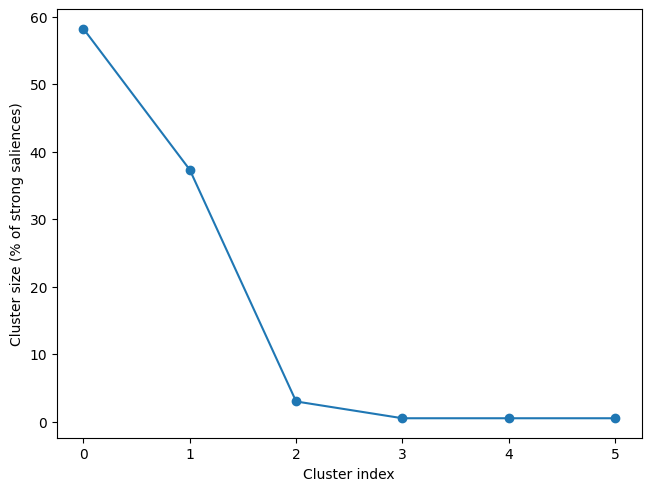

In [6]:
res.plot_cluster_sizes(lv_idx=0)

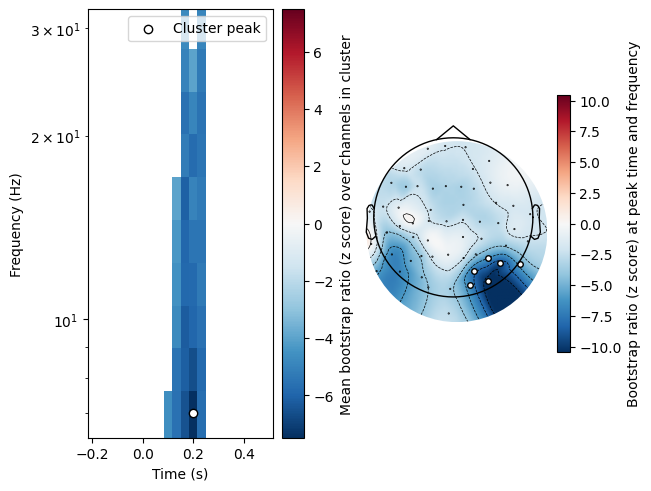

In [7]:
res.plot_cluster(lv_idx=0, cluster_idx=0)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Brain score'>)

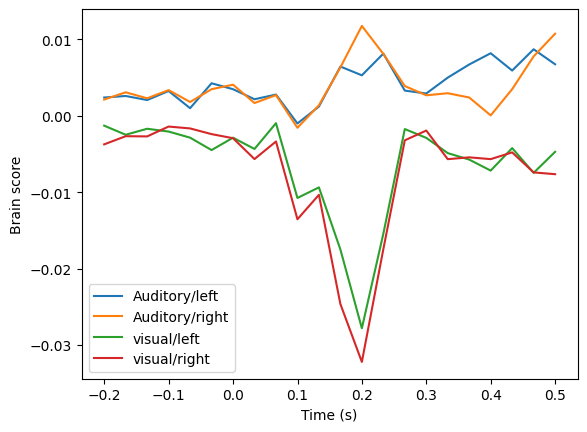

In [8]:
res.plot_marginal_brain_scores(lv_idx=0, margin='time')

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Brain score'>)

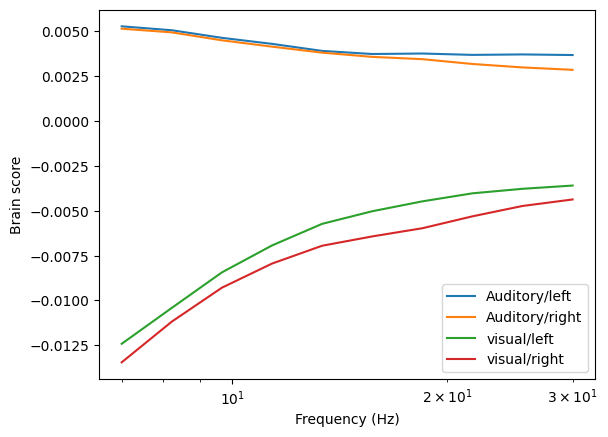

In [9]:
res.plot_marginal_brain_scores(lv_idx=0, margin='freq')